# Neural networks

We will implement a full artificial neural network to solve the concrete strenght problem

Mathematically, we can write this out as for a layer of neurons

$$
y_i = f(w_{ij}\, x_j + b_i)
$$

where summation of repeated indices is assumed, $\bf{w}$ is a rectangular weight matrix, $\bf{b}$ is the bias vector.
The neuron is nothing but a linear transformation of the input $\bf{b}$ 
followed by the application of a nonlinear function $f$,  called *activation
function*, to each component of the resulting vector. $\bf{y}$ is the output.
The length of the input and of the iput put can be different.

Some of the most popular activation functions are shown in the Figure. 
In the first column, we see the smooth functions Tanh and Softplus, while the second
column has “hard” versions of the activation functions to their left: Hardtanh and
ReLU. The ReLU is considered to be one of the best-performing general activation functions. 
The Sigmoid activation function, also known as the logistic function, is used where we explicitly want to 
move to restrain the results to the 0-1 range: for example, when the output
should be a probability. 
The widespread saturation of sigmoidal units can make gradient-based learning very difficult. For this reason,
their use as hidden units in feedforward networks is now discouraged. 

Finally, the LeakyReLU function modifies the standard
ReLU to have a small positive slope, rather than being strictly zero for negative inputs
(typically this slope is 0.01, but it’s shown here with slope 0.1 for clarity).

<div style="text-align: center;">
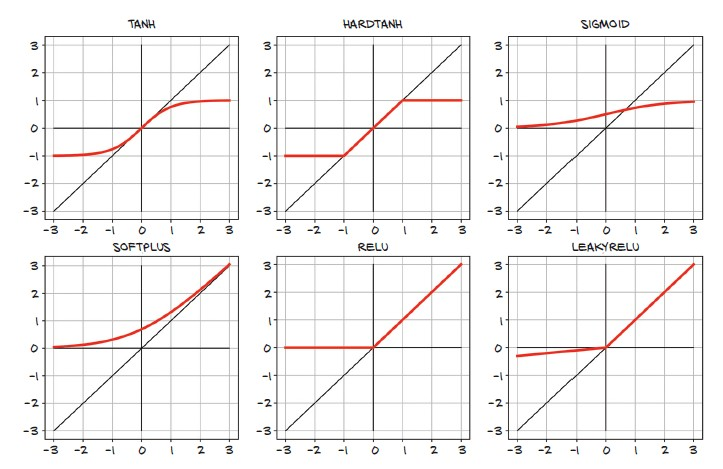
</div>

Some features of the activation functions. 
1. Are nonlinear: the nonlinearity allows the overall network to approximate more complex functions.
2. Are differentiable, so that gradients can be computed through them. Point discontinuities,
as we can see in Hardtanh or ReLU, are fine.
3. They have at least one sensitive range, where nontrivial changes to the input
result in a corresponding nontrivial change to the output. This is needed for
training.
4. Many of them have an insensitive (or saturated) range, where changes to the
input result in little or no change to the output.


A *multilayer neural network* , also called *feedforward nerual network* (FFN) is made up of a composition of $n$ layers with diffeent weights an biases.

\begin{gather}
x^{2}_i = f(w^{1}_{ij}\, x_j + b^{1}_i)
\\
x^{3}_i = f(w^{2}_{ij}\, x^{2}_j + b_i)
\\
...
\\
y_i = f(w_{ij}^{n}\, x^{n}_j + b_i)
\end{gather}

The output of a layer of neurons is used as an input for the following layer.
The internal layers are called *hidden*. In the Figure we see a FFN with 3 layers

<div style="text-align: center;">
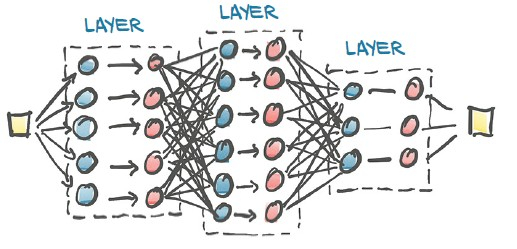
</div>

Fortunately, FFN with hidden layers provide a universal approximation
framework. Specifically, the universal approximation theorem (Hornik
et al., 1989; Cybenko, 1989) states that a feedforward network with a linear output
layer and at least one hidden layer with any “squashing” activation function (such
as the logistic sigmoid activation function) can approximate any function from 
one finite-dimensional space to another with any desired nonzero
amount of error, provided that the network is given enough hidden units. 

While the original theorems were first stated in terms of units with
activation functions that saturate for both very negative and very positive arguments,
universal approximation theorems have also been proved for a wider class
of activation functions, which includes the now commonly used rectified linear
unit (Leshno et al., 1993).


What makes using
deep neural networks so attractive is that it saves us from worrying too much about the
exact function that represents our data—whether it is quadratic, piecewise polynomial,
or something else. With a deep neural network model, we have a universal
approximator and a method to estimate its parameters. This approximator can be customized
to our needs, in terms of model capacity and its ability to model complicated
input/output relationships, just by composing simple building blocks

<div style="text-align: center;">
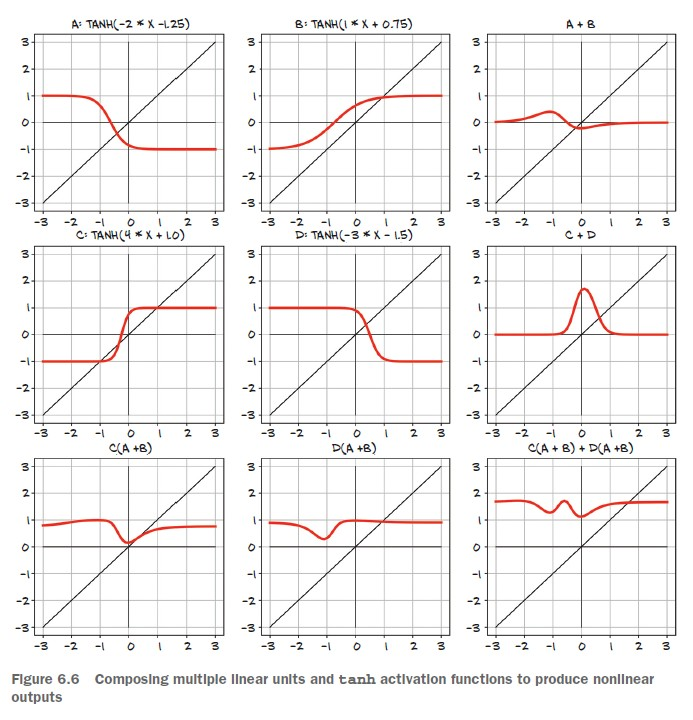
</div>

Deep neural networks give us the ability to approximate highly nonlinear phenomena without having
an explicit model for them. Instead, starting from a generic, untrained model, we
specialize it on a task by providing it with a set of inputs and outputs and a loss function
from which to backpropagate. Specializing a generic model to a task using examples is
what we refer to as learning, because the model wasn’t built with that specific task in
mind—no rules describing how that task worked were encoded in the model


## Concrete strength regression revisited

We start with the same input as in the regression notebook

In [350]:
import torch
import torch.nn as nn

torch.manual_seed(0) # set the seed to guarantee reproducibility of results 
N = 20 # number of data points
# True relationship: strength decreases with higher water content (simplified linear model)
true_params = torch.tensor([15.0, -8.0]) # Intercept, slope
# random generation of water-cement ratio
x = 0.2 + 0.4 * torch.rand(N)
# noisy measurements
y = true_params[0] + true_params[1] * x + 0.5 * torch.randn(N)

## The PyTorch nn module

PyTorch has a whole submodule dedicated to neural networks, called ``torch.nn``. 
It contains the building blocks needed to create all sorts of neural network architectures.
Those building blocks are called *modules*  even if such building
blocks are often referred to as layers in other frameworks. A PyTorch module is a
Python class deriving from the ``nn.Module`` base class. A module can have one or more
Parameter instances as attributes, which are tensors whose values are optimized
during the training process

Unsurprisingly, we can find a subclass of ``nn.Module`` called ``nn.Linear``, which applies
an affine transformation to its input (via the parameter attributes weight and bias)
and is equivalent to what we implemented earlier in our thermometer experiments

The constructor to ``nn.Linear`` accepts three arguments: the
number of input features (here the cement-water ratio), the number of output features (here the concrete strength), and whether the linear model includes a bias or not (default to True).

In [351]:
linear_model = nn.Linear(1, 1)
print(linear_model.weight)
print(linear_model.bias)


Parameter containing:
tensor([[0.1863]], requires_grad=True)
Parameter containing:
tensor([-0.7753], requires_grad=True)


Indeed, PyTorch ``nn.Module`` and its subclasses are designed to do so on multiple samples at
the same time, a *batch*. To accommodate multiple samples, modules expect the zeroth dimension
of the input to be the number of samples in the batch.
The module must be evaluated over data organized in the form of a 2D tensor of size $B × N_{in}$, where $B$ is the size of the batch and $N_{in}$ is the number of
input features


In [352]:
linear_model(x.unsqueeze(1))


tensor([[-0.7010],
        [-0.6808],
        [-0.7314],
        [-0.7282],
        [-0.7151],
        [-0.6908],
        [-0.7015],
        [-0.6712],
        [-0.7041],
        [-0.6909],
        [-0.7120],
        [-0.7081],
        [-0.7364],
        [-0.7255],
        [-0.7161],
        [-0.6994],
        [-0.6860],
        [-0.6784],
        [-0.7260],
        [-0.7170]], grad_fn=<AddmmBackward0>)

**Comments**

Why unsqueeze(1)? ``Linear(1,1)`` expects input like ``[batch_size, input_features]``, so it converts it to ``[batch_size,1]``

``grad_fn=...`` says simply this tensor is part of the computation graph


## Example: linear regression with PyTorch

Let us first regenerate the data and the training loop

In [353]:
n_val = int(0.2 * N)
torch.manual_seed(42)
shuffled_indices = torch.randperm(N)
train_indices = shuffled_indices[:-n_val]
val_indices = shuffled_indices[-n_val:]
print(train_indices)
print(val_indices)

x_train = x.unsqueeze(1)[train_indices]
x_val = x.unsqueeze(1)[val_indices]
y_train = y.unsqueeze(1)[train_indices]
y_val = y.unsqueeze(1)[val_indices]
print(x_train.squeeze(1))
print(y_train.squeeze(1))

def training_loop(n_epochs, optimizer, model, loss_fn, y_train, y_val, x_train, x_val):
    
    for epoch in range(1, n_epochs + 1):
        
        yp_train = model(x_train) 
        loss_train = loss_fn(yp_train, y_train)

        yp_val = model(x_val) 
        loss_val = loss_fn(yp_val, y_val)
        
        optimizer.zero_grad()
        loss_train.backward() 
        optimizer.step()

        if epoch == 1 or epoch % 1000 == 0:
            print(f"Epoch {epoch}, Training loss {loss_train.item():.4f},"
                  f" Validation loss {loss_val.item():.4f}")
            

tensor([ 2, 14, 18, 15,  1, 10,  0,  4,  6, 11,  8,  3,  7, 17, 13, 12])
tensor([19,  5, 16,  9])
tensor([0.2354, 0.3176, 0.2644, 0.4074, 0.5073, 0.3396, 0.3985, 0.3230, 0.3960,
        0.3607, 0.3823, 0.2528, 0.5586, 0.5200, 0.2675, 0.2089])
tensor([12.9462, 11.8595, 12.0942, 11.7383, 10.1641, 12.7527, 12.1114, 12.3083,
        12.1131, 12.3589, 11.8550, 13.9040, 10.6612, 10.6866, 12.9019, 13.9302])


Earlier, it was our responsibility to create parameters and pass them as the first argument
to ``optim.SGD``. Now we can use the ``parameters`` method to ask any ``nn.Module`` for
a list of parameters owned by it or any of its submodules. In our case
``linear_model.parameters()``

There’s one last bit that we can leverage from torch.nn: the loss. Indeed, nn comes
with several common loss functions, among them ``nn.MSELoss`` (MSE stands for Mean
Square Error), which is exactly what we defined earlier as our ``loss_fn``. Loss functions
in nn are still subclasses of ``nn.Module``

In [354]:
import torch.optim as optim

training_loop(
    n_epochs = 5000, 
    optimizer = optim.SGD(linear_model.parameters(),lr=1e-1),
    model = linear_model,
    loss_fn = nn.MSELoss(), # <1>
    y_train = y_train,
    y_val = y_val, 
    x_train = x_train,
    x_val = x_val)

print()
print(linear_model.weight)
print(linear_model.bias)

Epoch 1, Training loss 166.3844, Validation loss 151.6325
Epoch 1000, Training loss 0.2468, Validation loss 0.3547
Epoch 2000, Training loss 0.1991, Validation loss 0.2188
Epoch 3000, Training loss 0.1979, Validation loss 0.2017
Epoch 4000, Training loss 0.1978, Validation loss 0.1991
Epoch 5000, Training loss 0.1978, Validation loss 0.1986

Parameter containing:
tensor([[-9.0423]], requires_grad=True)
Parameter containing:
tensor([15.3930], requires_grad=True)


Everything else input into our training loop stays the same. Even our results remain
the same as before. Of course, getting the same results is expected, as a difference
would imply a bug in one of the two implementations or the two input vectors and permutations are differente. C

# A Neural Network for a slightly more complex data set

tensor([ 2, 14, 18, 15,  1, 10,  0,  4,  6, 11,  8,  3,  7, 17, 13, 12])
tensor([19,  5, 16,  9])
tensor([0.2105, 1.4737, 1.8947, 1.5789, 0.1053, 1.0526, 0.0000, 0.4211, 0.6316,
        1.1579, 0.8421, 0.3158, 0.7368, 1.7895, 1.3684, 1.2632])
tensor([ 0.8441,  0.6377,  0.3883, -0.8978,  0.0380,  1.0465, -0.5629,  0.7754,
        -0.9064,  0.9702, -0.6031,  0.6988, -0.0701, -0.3399,  1.5289,  1.6913])


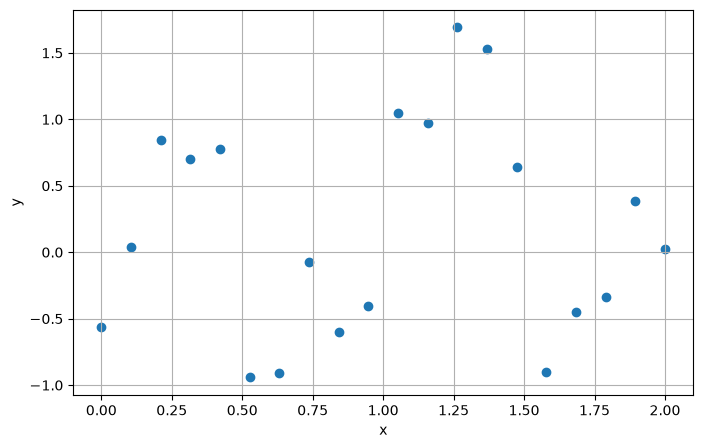

In [355]:
torch.manual_seed(0) # set the seed to guarantee reproducibility of results 
N = 20  # Small dataset to emphasize overfitting
x = torch.linspace(0, 2, N)
# noisy observations
y = torch.sin(2 * torch.pi * x) + 0.5 * torch.randn(N)

torch.manual_seed(42)
n_val = int(0.2 * N)
shuffled_indices = torch.randperm(N)
train_indices = shuffled_indices[:-n_val]
val_indices = shuffled_indices[-n_val:]
print(train_indices)
print(val_indices)

x_train = x.unsqueeze(1)[train_indices]
x_val = x.unsqueeze(1)[val_indices]
y_train = y.unsqueeze(1)[train_indices]
y_val = y.unsqueeze(1)[val_indices]
print(x_train.squeeze(1))
print(y_train.squeeze(1))

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.scatter(x, y, label="Sinusoidal data")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

Let’s build the simplest possible neural network: a linear module, followed
by an activation function, feeding into another linear module. The first linear + activation
layer is commonly referred to as a hidden layer for historical reasons, since its outputs
are not observed directly but fed into the output layer. While the input and output
of the model are both of size 1 (they have one input and one output feature), the size
of the output of the first linear module is usually larger than 1.

In [356]:
dimlayer = 15
seq_model = nn.Sequential(
            nn.Linear(1, dimlayer), # <1>
            nn.Tanh(),
            nn.Linear(dimlayer, 1)) # <2>

seq_model

Sequential(
  (0): Linear(in_features=1, out_features=15, bias=True)
  (1): Tanh()
  (2): Linear(in_features=15, out_features=1, bias=True)
)

The end result is a model that takes the inputs expected by the first module specified
as an argument of ``nn.Sequential``, passes intermediate outputs to subsequent modules,
and produces the output returned by the last module. The model fans out from
1 input feature to 13 hidden features, passes them through a $tanh$ activation, and linearly
combines the resulting 13 numbers into 1 output feature

## Parameters

Calling ``model.parameters()`` will collect weight and bias from both the first and second
linear modules. It’s instructive to inspect the parameters in this case by printing
their shapes

In [357]:
[param.shape for param in seq_model.parameters()]

[torch.Size([15, 1]), torch.Size([15]), torch.Size([1, 15]), torch.Size([1])]

In [358]:
for name, param in seq_model.named_parameters():
    print(name, param.shape)

0.weight torch.Size([15, 1])
0.bias torch.Size([15])
2.weight torch.Size([1, 15])
2.bias torch.Size([1])


Epoch 1, Training loss 0.6728, Validation loss 0.6791
Epoch 1000, Training loss 0.0619, Validation loss 0.7128
Epoch 2000, Training loss 0.0448, Validation loss 0.8296
Epoch 3000, Training loss 0.0412, Validation loss 0.6517
Epoch 4000, Training loss 0.0394, Validation loss 0.5701
Epoch 5000, Training loss 0.0376, Validation loss 0.5345
Epoch 6000, Training loss 0.0358, Validation loss 0.4832
Epoch 7000, Training loss 0.0341, Validation loss 0.4739
Epoch 8000, Training loss 0.0206, Validation loss 0.4753
Epoch 9000, Training loss 0.0081, Validation loss 0.6376
Epoch 10000, Training loss 0.0040, Validation loss 0.6290


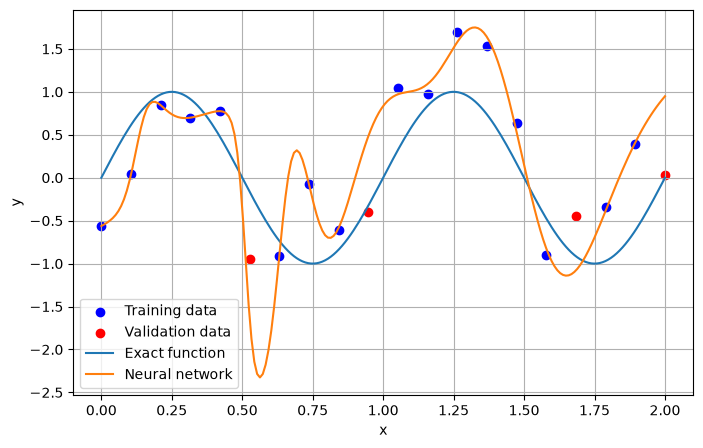

In [359]:
#optimizer = optim.SGD(seq_model.parameters(), lr=1e-1)
optimizer = optim.Adam(seq_model.parameters(), lr=1e-1)

# use first 1000 epochs, then 5000, then 10^4
training_loop(
    n_epochs = 10000, 
    optimizer = optimizer,
    model = seq_model,
    loss_fn = nn.MSELoss(),
    y_train = y_train,
    y_val = y_val, 
    x_train = x_train,
    x_val = x_val)

# plots comparisons
x_plot = torch.linspace(0, 2, 200).unsqueeze(1)
y_exact = torch.sin(2 * torch.pi * x_plot)

with torch.no_grad():
    y_pred = seq_model(x_plot)

plt.figure(figsize=(8, 5))
plt.scatter(x_train, y_train, color="blue", label="Training data")
plt.scatter(x_val, y_val, color="red", label="Validation data")
plt.plot(x_plot.squeeze(), y_exact.squeeze(), label="Exact function")
plt.plot(x_plot.squeeze(), y_pred.squeeze(), label="Neural network")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()
    

# Exercises

Create a Python file with the overall procedure and vary the number of neurons in the hidden layer and the level the noise. What happen with a very large noise? (e.g. 0.5)